# About

This project evaluates six classification algorithms namely Logistic Regression, Naive Bayes, K-Nearest Neighbors, Decision Tree, Random Forest, and XGBoost using the Bank Marketing dataset to predict customer subscription to a term deposit. The dataset is highly imbalanced, with far fewer “yes” cases than “no,” making metrics such as precision, recall, F1-score, and AUC more meaningful than accuracy alone. To ensure fairness, a consistent preprocessing pipeline was applied across all models, including scaling numerical features, one-hot encoding categorical variables, and using a 70/30 train-test split.

**Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

**Load Dataset**

In [9]:
df = pd.read_csv("/content/bank-additional-full.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [10]:
df.info()

# Checking target variable distribution
print("\nTarget distribution:")
print(df['y'].value_counts(normalize=True))

# Checking missing values (if any)
print("\nMissing values per column:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The dataset has 41188 entries, with no missing values.



In [11]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Define Features and Target**

In [12]:
# Separating features (X) the input and target (y) the output
X = df.drop(columns=['y'])
y = df['y']    # 'yes' / 'no'


**Identify Numeric and Categorical Columns**

In [13]:
# Identifing numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


**Preprocessing Pipeline**

In [14]:
# Preprocessing for numeric and categorical data
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False  # Changed sparse=False to sparse_output=False
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

**StandardScaler** for feature scaling of numerical features so they have a mean of 0 and a standard deviation of 1.
**OneHotEncoder**  converts categorical  features into a numerical format that algorithms understand.
**ColumnTransformer**  allows the application of different transformers (ie StandardScaler or OneHotEncoder) on different columns of the dataset simultaneously.


**Train/Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # preserve class distribution
)

# Encode y for models that expect numerical target (e.g., GaussianNB, XGBoost)
y_train_encoded = y_train.map({'no': 0, 'yes': 1})
y_test_encoded = y_test.map({'no': 0, 'yes': 1})

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (28831, 20)
Test size: (12357, 20)




1. Splitting the data set into 70 training: 30 test
2.   Executing the rules above on the dataset



In [16]:
def evaluate(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Determine original labels type and positive label for metrics
    if y_test.dtype == 'object':
        original_pos_label = 'yes'
        labels_for_cm = ["no", "yes"]
        # Convert y_pred to original string labels if it's numeric (e.g., from XGBoost)
        if y_pred.dtype != 'object':
            y_pred_for_report = pd.Series(y_pred).map({0: 'no', 1: 'yes'})
        else:
            y_pred_for_report = y_pred
    else: # y_test is numerical (0/1)
        original_pos_label = 1
        labels_for_cm = [0, 1]
        y_pred_for_report = y_pred # Already numeric, matches y_test type

    # Convert y_test to binary (0/1) for AUC and other calculations that expect numeric
    # This also handles case where y_test is already 0/1
    y_test_binary = (y_test == original_pos_label).astype(int)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test_binary, y_proba)
    else:
        y_proba = None
        auc = None

    accuracy = accuracy_score(y_test, y_pred_for_report)
    precision = precision_score(y_test, y_pred_for_report, pos_label=original_pos_label)
    recall = recall_score(y_test, y_pred_for_report, pos_label=original_pos_label)
    f1 = f1_score(y_test, y_pred_for_report, pos_label=original_pos_label)

    print(f"\n==== {model_name} ====\n")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("AUC      :", auc)

    print("\nClassification Report:\n", classification_report(y_test, y_pred_for_report))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_for_report, labels=labels_for_cm)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    if y_proba is not None:
        RocCurveDisplay.from_predictions(
            y_test_binary, y_proba # Always use binary for ROC curve
        )
        plt.title(f"{model_name} – ROC Curve")
        plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

# Model by Model

**Model 1: Logistic Regression**


==== Logistic Regression ====

Accuracy : 0.8625880067977665
Precision: 0.44562899786780386
Recall   : 0.9008620689655172
F1 Score : 0.5962910128388017
AUC      : 0.939619662353046

Classification Report:
               precision    recall  f1-score   support

          no       0.99      0.86      0.92     10965
         yes       0.45      0.90      0.60      1392

    accuracy                           0.86     12357
   macro avg       0.72      0.88      0.76     12357
weighted avg       0.92      0.86      0.88     12357



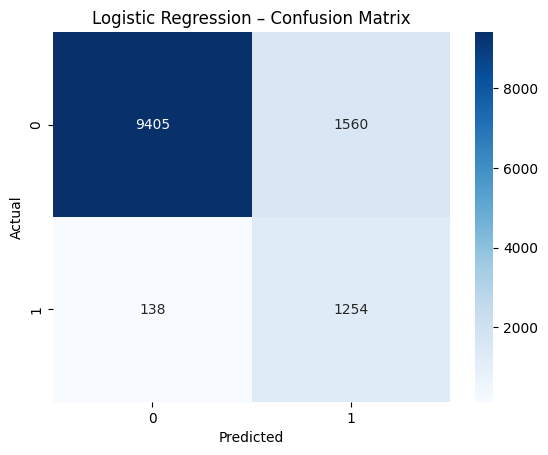

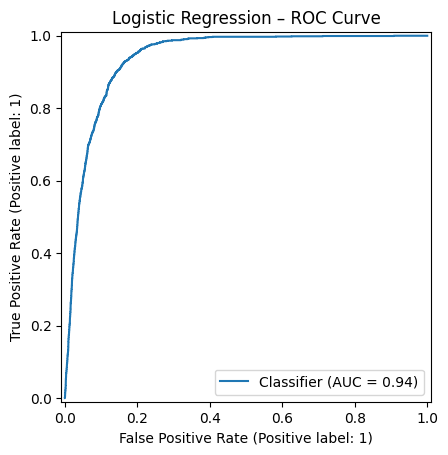

In [17]:
results = [] # Initializing results list

log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)
results.append(evaluate("Logistic Regression", log_reg, X_test, y_test))

Logistic Regression achieved a strong overall accuracy of **0.86** and an excellent AUC of **0.94**, showing very good probability-ranking ability
It has high recall  of **0.90** for the “yes” class, meaning it successfully identified most customers who subscribed.
However, the precision for “yes” is  low  at **0.45**, indicating many false positives in predictions for deposit subscription.
The confusion matrix confirms this trade-off: the model captures positives well but misclassifies many non-subscribers as subscribers, resulting in a moderate F1-score of **0.60**.

**Model 2: Naive Bayes (GaussianNB)**


==== Naive Bayes (GaussianNB) ====

Accuracy : 0.8213967791535163
Precision: 0.3494643516808275
Recall   : 0.6795977011494253
F1 Score : 0.4615759941449134
AUC      : 0.8362872855637845

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89     10965
           1       0.35      0.68      0.46      1392

    accuracy                           0.82     12357
   macro avg       0.65      0.76      0.68     12357
weighted avg       0.89      0.82      0.84     12357



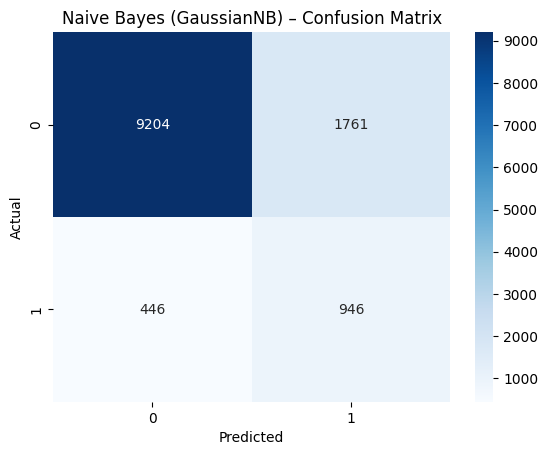

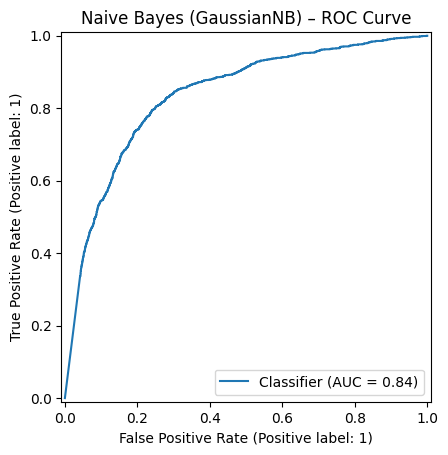

In [27]:
nb_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', GaussianNB())
])

# GaussianNB expects numerical targets
nb_model.fit(X_train, y_train_encoded)
results.append(evaluate("Naive Bayes (GaussianNB)", nb_model, X_test, y_test_encoded))

Naive Bayes achieved moderate accuracy **0.82** but have weak precision for the “yes” class at **0.35**, indicating many false positives.
Its recall for “yes” was better  at **0.68**, meaning it captured more actual subscribers but with low reliability.
The AUC of **0.84** and ROC curve show fair discrimination ability, but overall performance is limited by the model’s strong independence assumptions.

**Model 3: K-Nearest Neighbors (KNN)**


==== KNN ====

Accuracy : 0.9044266407704136
Precision: 0.6095534787123572
Recall   : 0.42169540229885055
F1 Score : 0.49851380042462845
AUC      : 0.8692953939127106

Classification Report:
               precision    recall  f1-score   support

          no       0.93      0.97      0.95     10965
         yes       0.61      0.42      0.50      1392

    accuracy                           0.90     12357
   macro avg       0.77      0.69      0.72     12357
weighted avg       0.89      0.90      0.90     12357



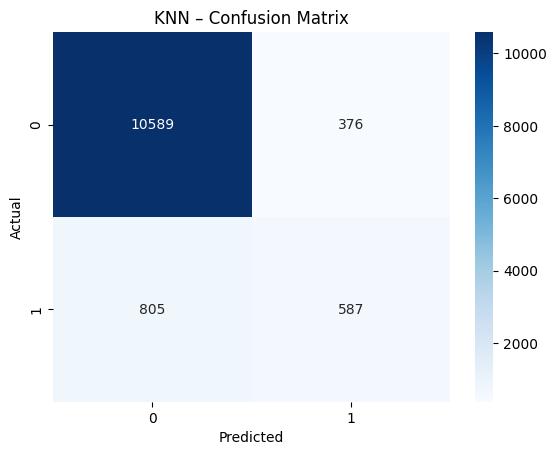

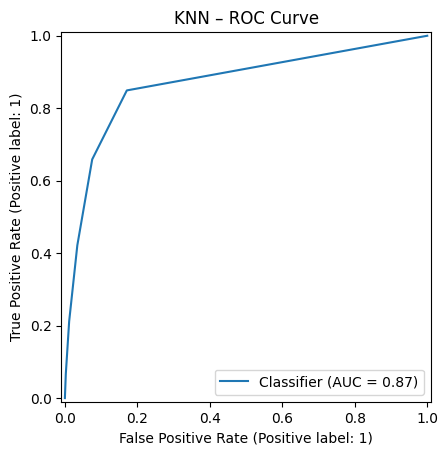

In [28]:
knn_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
results.append(evaluate("KNN", knn_model, X_test, y_test))

KNN achieved high overall accuracy of** 0.90**, but its recall for the “yes” class was low at **0.42**, meaning it missed many actual subscribers.
Precision for “yes” was moderate at **0.61**, but the model struggled with the minority class, as seen in the high number of false negatives **805**.
The AUC of **0.87** shows fair discriminative ability, but overall performance is limited by high dimensionality and KNN’s sensitivity to distance.

**Model 4: Decision Tree**


==== Decision Tree ====

Accuracy : 0.8892125920530873
Precision: 0.5089913995308835
Recall   : 0.4676724137931034
F1 Score : 0.48745788094346687
AUC      : 0.705199635989119

Classification Report:
               precision    recall  f1-score   support

          no       0.93      0.94      0.94     10965
         yes       0.51      0.47      0.49      1392

    accuracy                           0.89     12357
   macro avg       0.72      0.71      0.71     12357
weighted avg       0.89      0.89      0.89     12357



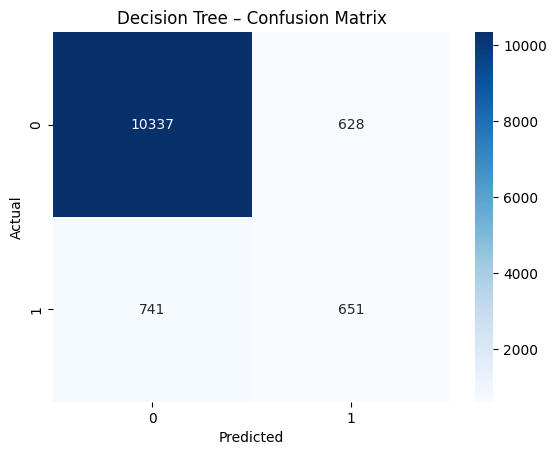

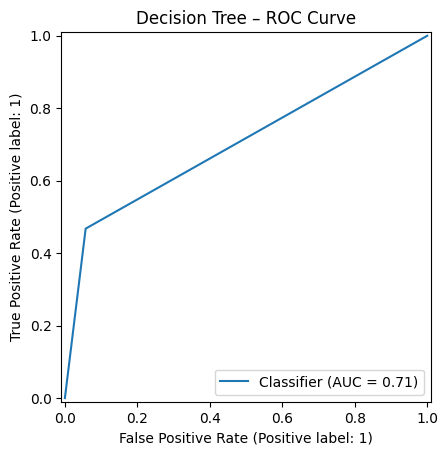

In [29]:
dt_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

dt_model.fit(X_train, y_train)
results.append(evaluate("Decision Tree", dt_model, X_test, y_test))

The Decision Tree achieved an accuracy of **0.89** but a weak recall for the “yes” class at **0.47**, indicating many missed subscribers.
Precision and F1 for “yes” were moderate, reflecting overfitting and unstable generalization on the minority class.
With a low AUC of **0.71** and a nearly linear ROC curve, the model shows limited discrimination ability compared to ensemble models.

**Model 5: Random Forest**


==== Random Forest ====

Accuracy : 0.9110625556364813
Precision: 0.681087762669963
Recall   : 0.3958333333333333
F1 Score : 0.5006815084052704
AUC      : 0.9445160869747525

Classification Report:
               precision    recall  f1-score   support

          no       0.93      0.98      0.95     10965
         yes       0.68      0.40      0.50      1392

    accuracy                           0.91     12357
   macro avg       0.80      0.69      0.73     12357
weighted avg       0.90      0.91      0.90     12357



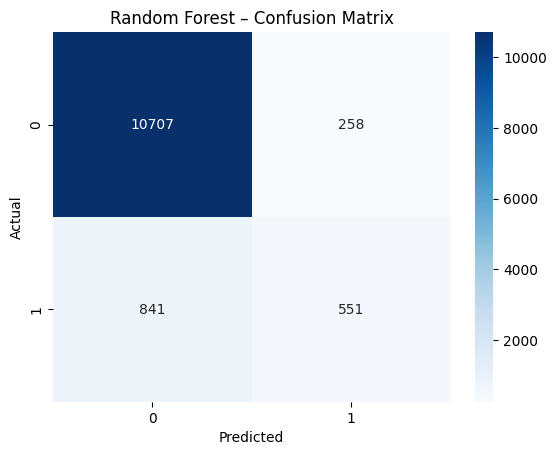

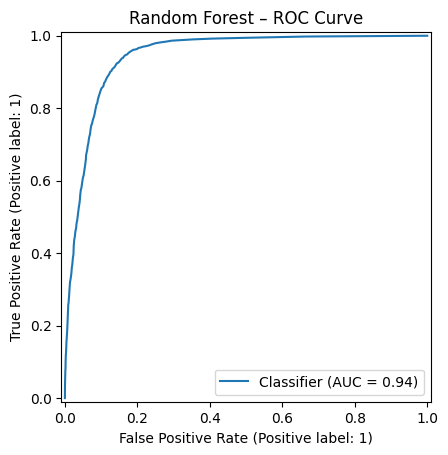

In [31]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf_model, X_test, y_test))

Random Forest had a high accuracy of **0.91** and strong precision of **0.68,** but recall is low at **0.40**, meaning it missed many actual subscribers.
The confusion matrix also shows many false negatives at 841, reducing the F1-score to **0.50** despite excellent performance on the majority class.
With a high AUC of **0.94**, the model ranks probabilities very well, but struggles to correctly capture the minority “yes” class .

**Model 6: XGBoost**


==== XGBoost (default) ====

Accuracy : 0.9176984705025492
Precision: 0.6660761736049602
Recall   : 0.5402298850574713
F1 Score : 0.5965886552955176
AUC      : 0.9500975543919785

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95     10965
           1       0.67      0.54      0.60      1392

    accuracy                           0.92     12357
   macro avg       0.80      0.75      0.78     12357
weighted avg       0.91      0.92      0.91     12357



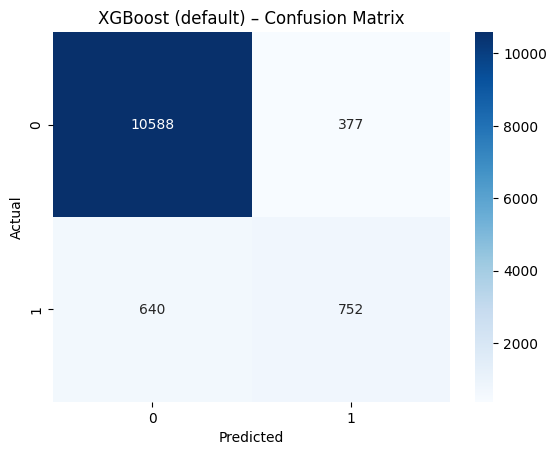

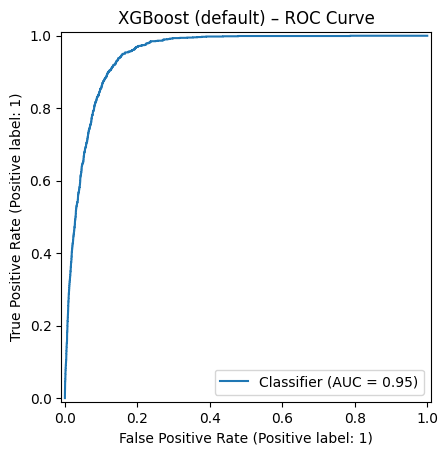

In [33]:
xgb_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        tree_method='hist'  # faster
    ))
])

xgb_model.fit(X_train, y_train_encoded)
# Evaluate using the original X_test and the encoded y_test, the evaluate function will handle conversions
results.append(evaluate("XGBoost (default)", xgb_model, X_test, y_test_encoded))

XGBoost achieved a strong accuracy of **0.92**, good precision at **0.67**, and recall for the “yes” class at **0.54**.
It correctly identified  subscribers with F1-score at **0.60 ** for the minority class.
With an excellent AUC of 0.95 and a sharply rising ROC curve, XGBoost shows outstanding discriminative ability and robust prediction quality.

In [23]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1', ascending=False))

,Model,Accuracy,Precision,Recall,F1,AUC
5,XGBoost (default),0.917698,0.666076,0.540230,0.596589,0.950098
0,Logistic Regression,0.862588,0.445629,0.900862,0.596291,0.939620
4,Random Forest,0.911063,0.681088,0.395833,0.500682,0.944516
2,KNN,0.904427,0.609553,0.421695,0.498514,0.869295
3,Decision Tree,0.889213,0.508991,0.467672,0.487458,0.705200
1,Naive Bayes (GaussianNB),0.821397,0.349464,0.679598,0.461576,0.836287


The table ranks all six  models based on F1-score,
XGBoost achieved the highest F1-score **0.5966**, it is the best performer due to strong precision, good recall, and the highest AUC **0.95**.
Logistic Regression follows closely with a similar F1-score **0.5963**, driven mainly by its very high recall of **0.90**.
Random Forest and KNN show moderate F1-scores, while Decision Tree and Naive Bayes have the weakest performance, confirming they struggle more with detecting the minority “yes” class.

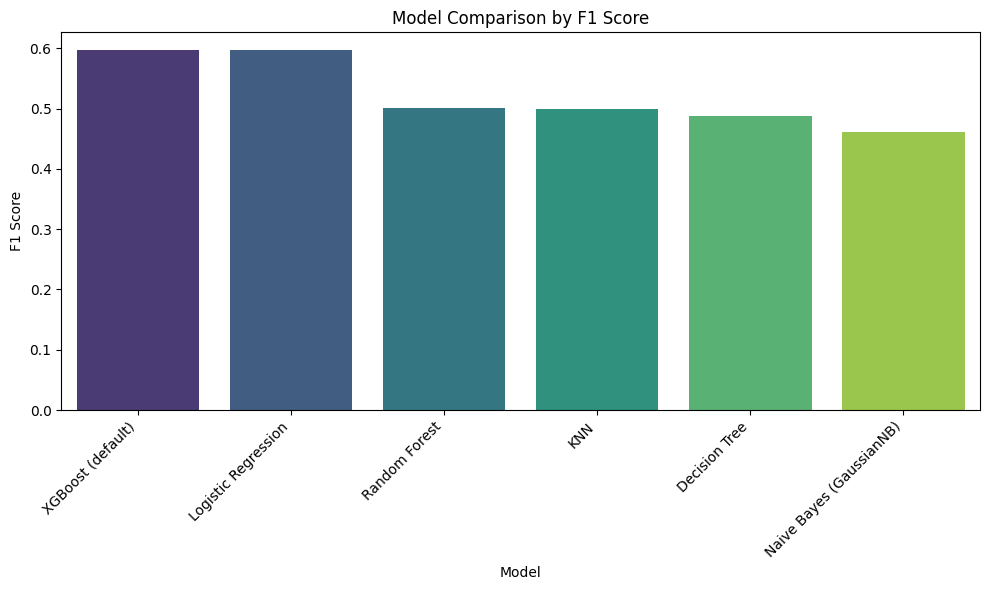

In [34]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='F1', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1', hue='Model', data=results_df_sorted, palette='viridis', legend=False)
plt.title('Model Comparison by F1 Score')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary
The  analysis demonstrates that XGBoost is the best-performing classifier for predicting term-deposit subscriptions. It achieved the highest F1-score and AUC, indicating the strongest balance between detecting actual subscribers and minimizing false predictions. Logistic Regression also performed well, especially in recall, making it a good interpretable alternative. Random Forest provided stability but lacked sufficient sensitivity to minority cases. Meanwhile, Naive Bayes, KNN, and Decision Tree exhibited limitations tied to the dataset’s structure and class imbalance.

**Hyperparameters tuning**

**Model 7: Random Forest**




/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


Best RF parameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}

==== Random Forest (tuned) ====

Accuracy : 0.9117908877559278
Precision: 0.68875
Recall   : 0.3958333333333333
F1 Score : 0.5027372262773723
AUC      : 0.9430324281543678

Classification Report:
               precision    recall  f1-score   support

          no       0.93      0.98      0.95     10965
         yes       0.69      0.40      0.50      1392

    accuracy                           0.91     12357
   macro avg       0.81      0.69      0.73     12357
weighted avg       0.90      0.91      0.90     12357



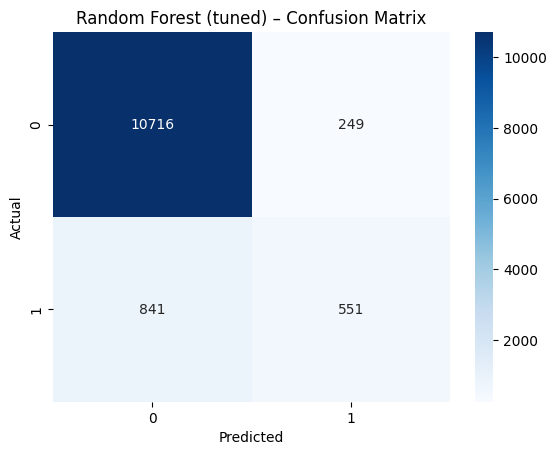

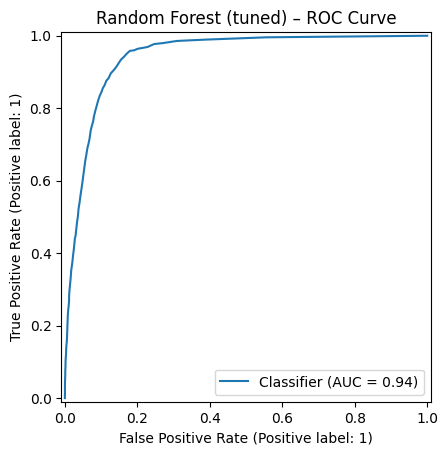

{'Model': 'Random Forest (tuned)',
 'Accuracy': 0.9117908877559278,
 'Precision': 0.68875,
 'Recall': 0.3958333333333333,
 'F1': 0.5027372262773723,
 'AUC': np.float64(0.9430324281543678)}

In [35]:
rf_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

rf_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid, # Corrected parameter name
    cv=3,
    scoring='f1',   # focus on F1 for imbalanced data
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF parameters:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_
evaluate("Random Forest (tuned)", best_rf, X_test, y_test)

The tuned Random Forest achieved high accuracy of (0.91), excellent precision of (0.69), but recall remained low at (0.40). This implies  many actual subscribers were still missed. The confusion matrix confirms high false negatives despite strong performance on the majority class. The AUC of 0.94 shows excellent discriminative ability, indicating the model ranks probabilities well even when the decision threshold limits recall. Therefore Hyperparameter tuning improved stability but did not significantly resolve the recall deficiency for the minority class.

**Issues faced**

1.   Class Imbalance
The dataset contains less “yes” cases compared to “no,” which made it difficult for models to correctly identify subscribers. Many models produced high accuracy but low recall for the minority class, causing biased predictions and misleading metrics.
2. High Dimensionality After One-Hot Encoding
Encoding categorical variables dramatically increased the number of input features. This negatively affected  KNN and Decision Tree, leading to slower training, overfitting, and poor generalization.
3. Computational Cost of Tuning. Hyperparameter tuning using GridSearchCV and RandomizedSearchCV required significant computational time, especially for Random Forest

